In [4]:
# Import necessary libraries
import pandas_datareader as reader
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import yfinance as yf
import numpy as np
from scipy.stats import norm
import pandas as pd

In [5]:
# Define starting & end dates

endDate = dt.datetime.now()
startDate = endDate - pd.DateOffset(months=12)

# Define the portfolio stocks
tickers = ['VWCE.DE','IUSN.DE','IWVL.L','EIMI.L', 'EGLN.L', 'CMOP.L', 'BITC.SW','EUNA.DE']

In [6]:
# Fetch the data (Only Adjusted Close Column)
data = yf.download(tickers,startDate,endDate)['Close']
data = data.dropna()

# Print last 10 rows of the data
print(data.tail(10))

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  8 of 8 completed

Ticker        BITC.SW  CMOP.L     EGLN.L     EIMI.L  EUNA.DE  IUSN.DE  \
Date                                                                    
2026-08-28  56.470001  2570.0  76.180000  55.450001   4.8930    9.199   
2026-09-01  55.419998  2616.0  73.010002  55.279999   4.8805    9.075   
2026-09-02  55.080002  2641.0  73.129997  55.070000   4.8709    9.066   
2026-09-03  55.380001  2627.0  75.150002  55.230000   4.8821    9.146   
2026-09-04  56.540001  2621.0  74.114998  56.040001   4.8862    9.152   
2026-09-07  56.060001  2639.0  73.620003  56.299999   4.8772    9.143   
2026-09-08  55.830002  2635.0  73.449997  56.450001   4.8841    9.128   
2026-09-09  55.830002  2656.0  73.419998  56.169998   4.8646    9.017   
2026-09-10  54.980000  2687.0  72.900002  55.209999   4.8457    8.938   
2026-09-11  56.060001  2668.0  73.080002  55.709999   4.8467    8.998   

Ticker         IWVL.L     VWCE.DE  
Date                               
2026-08-28  81.790001  168.539993  
2026-09-01  81.

In [7]:
# Stock Returns
returns = np.log(data).diff()
# Exclude first row of N/A
returns = returns.dropna()

returns.tail(10)

Ticker,BITC.SW,CMOP.L,EGLN.L,EIMI.L,EUNA.DE,IUSN.DE,IWVL.L,VWCE.DE
Date,,,,,,,,
2026-08-28,0.001418,0.010168,-0.004715,0.001263,-0.001430,0.000326,0.006009,0.008341
2026-09-01,-0.018769,0.017741,-0.042503,-0.003071,-0.002558,-0.013571,-0.001101,-0.011457
2026-09-02,-0.006154,0.009511,0.001642,-0.003806,-0.001969,-0.000992,-0.000735,0.001200
2026-09-03,0.005432,-0.005315,0.027247,0.002901,0.002297,0.008785,0.013021,0.007406
2026-09-04,0.020730,-0.002287,-0.013868,0.014559,0.000839,0.000656,0.005787,-0.001072
2026-09-07,-0.008526,0.006844,-0.006701,0.004629,-0.001844,-0.000984,0.006351,-0.000596
2026-09-08,-0.004111,-0.001517,-0.002312,0.002661,0.001414,-0.001642,-0.005750,-0.001193
2026-09-09,0.000000,0.007938,-0.000409,-0.004973,-0.004000,-0.012235,-0.005783,-0.008149
2026-09-10,-0.015342,0.011604,-0.007108,-0.017239,-0.003893,-0.008800,-0.008494,-0.005792


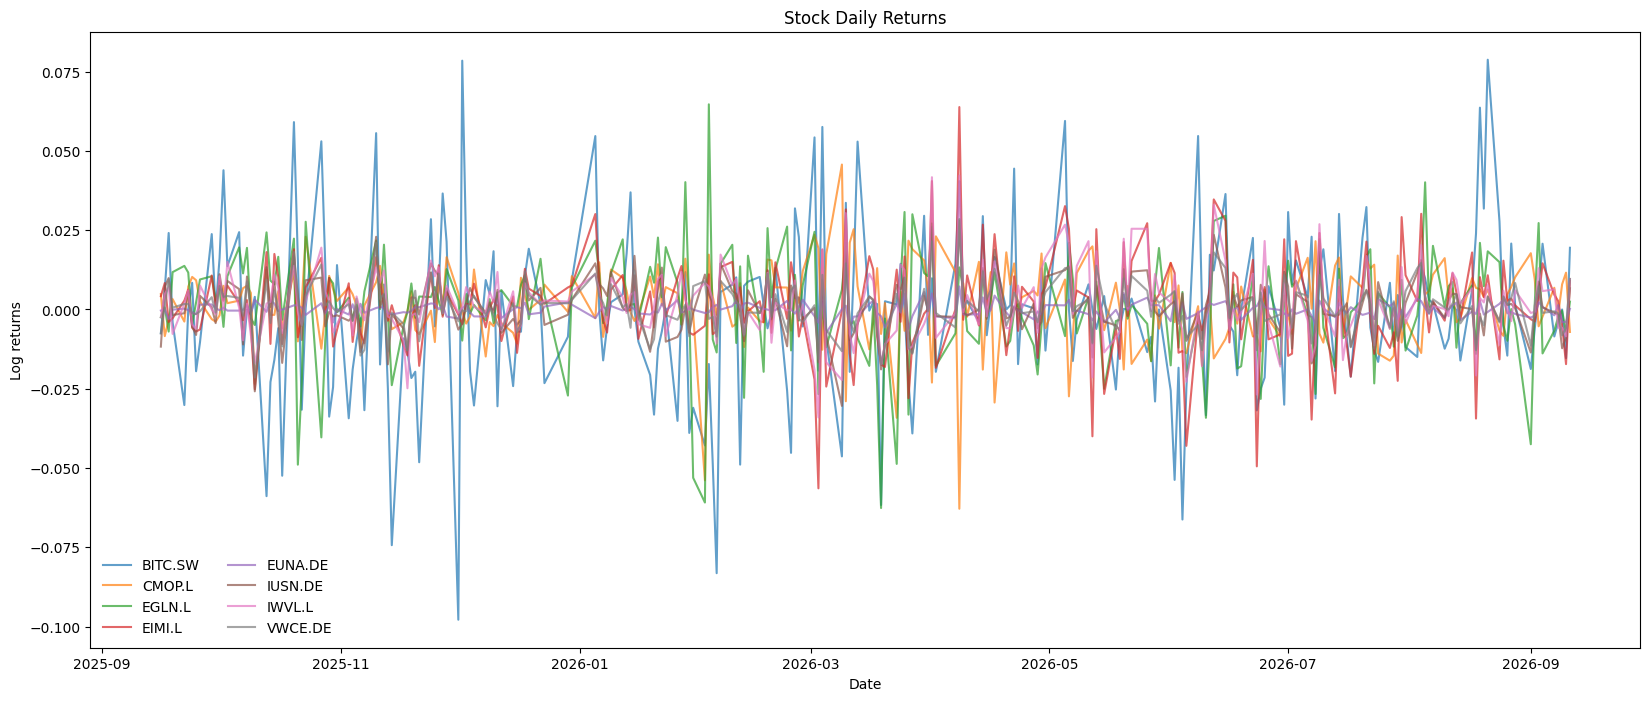

In [8]:
plt.figure(figsize=(20,8))

for col in returns.columns:
    plt.plot(
        returns.index,
        returns[col],
        label=col,
        alpha=0.7,
        linewidth=1.5
    )

plt.xlabel("Date")
plt.ylabel("Log returns")
plt.title("Stock Daily Returns")
plt.legend(ncol=2, frameon=False)
plt.show()

In [9]:
# Calculate mean returns for each stock
avg_returns = returns.mean()
avg_returns

Ticker
BITC.SW   -0.001540
CMOP.L     0.001514
EGLN.L     0.000773
EIMI.L     0.001074
EUNA.DE   -0.000074
IUSN.DE    0.000764
IWVL.L     0.001745
VWCE.DE    0.000761
dtype: float64

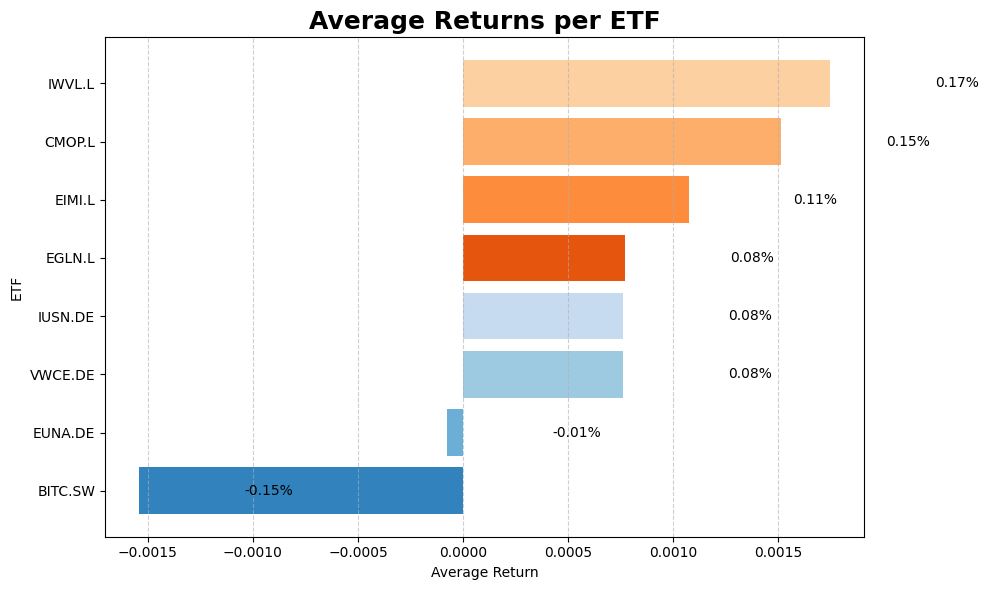

In [10]:
# Sort average returns descending
avg_returns_sorted = avg_returns.sort_values(ascending=True)  # ascending for horizontal bar chart

# Plot
plt.figure(figsize=(10,6))
bars = plt.barh(avg_returns_sorted.index, avg_returns_sorted.values, color=plt.cm.tab20c.colors)

# Add value labels at the end of bars
for i, v in enumerate(avg_returns_sorted.values):
    plt.text(v + 0.0005, i, f"{v:.2%}", va='center', fontsize=10)

plt.title("Average Returns per ETF", fontsize=18, weight='bold')
plt.xlabel("Average Return")
plt.ylabel("ETF")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

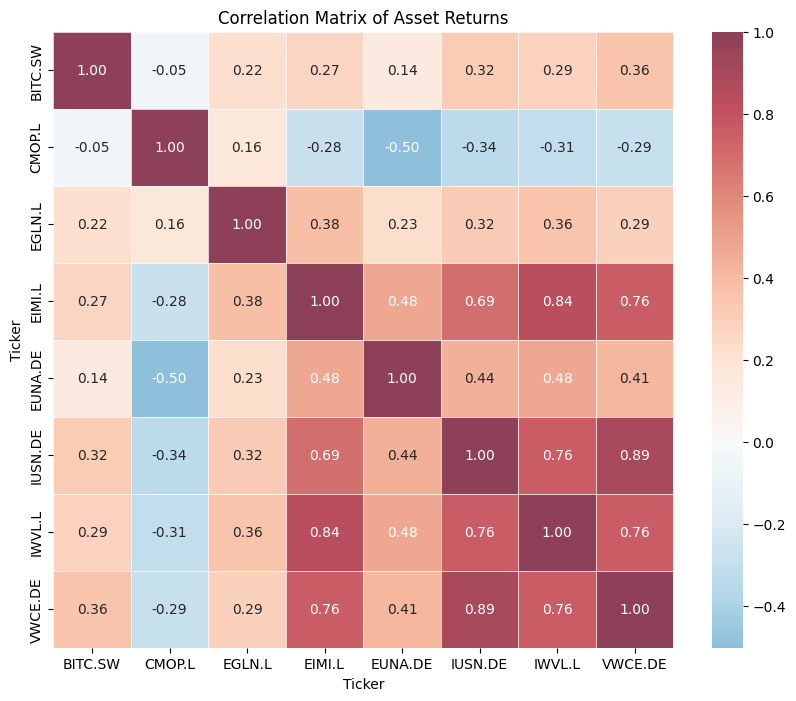

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(
    returns.corr(),
    cmap="RdBu_r",
    center=0,
    alpha=0.75,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Asset Returns")
plt.show()


In [20]:
simple_returns = np.exp(returns) - 1
rf = 0.02487  # Germany 3 Month Bond Yield

In [21]:
# Weights: VWCE: 35%, IUSN: 15%, IWVL: 10%, EIMI: 15%, EGLN: 5%, CMOP: 5%, BITC: 15%, EUNA: 0%
w_lover = np.array([0.35, 0.15, 0.10, 0.15, 0.05, 0.05, 0.15, 0.00])
port_lover = simple_returns.dot(w_lover)

sharpe_lover = (port_lover.mean() * 252 - rf) / (port_lover.std() * np.sqrt(252))
var95_lover = port_lover.quantile(0.05)

print(f"Risk-Lover Sharpe Ratio: {sharpe_lover:.2f}")
print(f"Risk-Lover 95% Daily VaR: {var95_lover:.2%}")

Risk-Lover Sharpe Ratio: 0.40
Risk-Lover 95% Daily VaR: -1.65%


In [22]:
# Weights: VWCE: 40%, IUSN: 5%, IWVL: 8%, EIMI: 7%, EGLN: 8%, CMOP: 7%, BITC: 5%, EUNA: 20%
w_neutral = np.array([0.40, 0.05, 0.08, 0.07, 0.08, 0.07, 0.05, 0.20])
port_neutral = simple_returns.dot(w_neutral)

sharpe_neutral = (port_neutral.mean() * 252 - rf) / (port_neutral.std() * np.sqrt(252))
var95_neutral = port_neutral.quantile(0.05)

print(f"Risk-Neutral Sharpe Ratio: {sharpe_neutral:.2f}")
print(f"Risk-Neutral 95% Daily VaR: {var95_neutral:.2%}")

Risk-Neutral Sharpe Ratio: -0.06
Risk-Neutral 95% Daily VaR: -1.87%


In [23]:
# Weights: VWCE: 30%, IUSN: 0%, IWVL: 5%, EIMI: 0%, EGLN: 10%, CMOP: 5%, BITC: 0%, EUNA: 50%
w_averse = np.array([0.30, 0.00, 0.05, 0.00, 0.10, 0.05, 0.00, 0.50])
port_averse = simple_returns.dot(w_averse)

sharpe_averse = (port_averse.mean() * 252 - rf) / (port_averse.std() * np.sqrt(252))
var95_averse = port_averse.quantile(0.05)

print(f"Risk-Averse Sharpe Ratio: {sharpe_averse:.2f}")
print(f"Risk-Averse 95% Daily VaR: {var95_averse:.2%}")

Risk-Averse Sharpe Ratio: 0.02
Risk-Averse 95% Daily VaR: -1.59%


,Portfolio,Sharpe Ratio,95% Daily VaR (%)
0,Risk-Lover,0.40,-1.65%
1,Risk-Neutral,-0.06,-1.87%
2,Risk-Averse,0.02,-1.59%


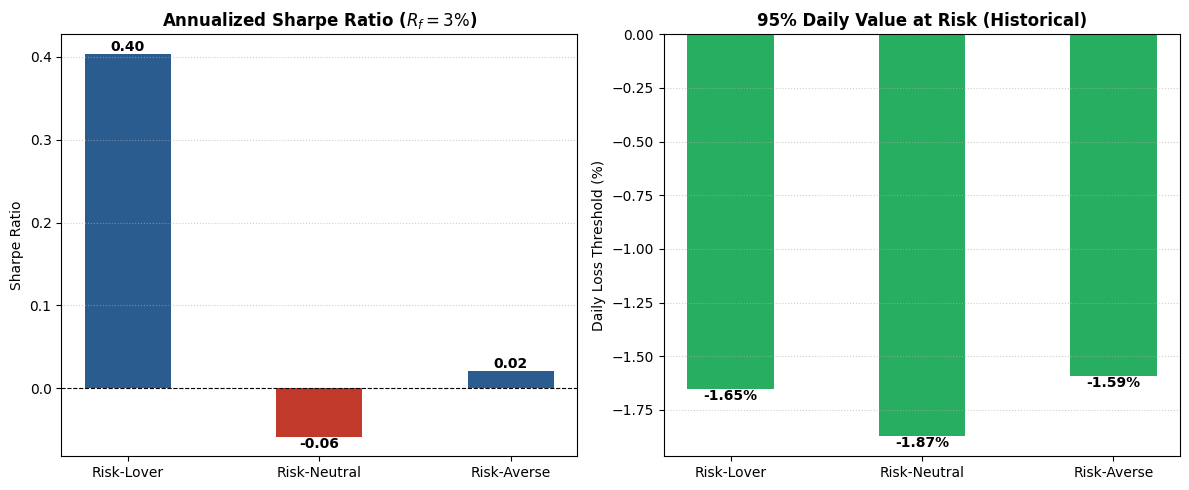

In [24]:
# 1. Summary DataFrame
df_summary = pd.DataFrame({
    'Portfolio': ['Risk-Lover', 'Risk-Neutral', 'Risk-Averse'],
    'Sharpe Ratio': [sharpe_lover, sharpe_neutral, sharpe_averse],
    '95% Daily VaR (%)': [var95_lover * 100, var95_neutral * 100, var95_averse * 100]
})

# Display formatted table in notebook
display(df_summary.style.format({'Sharpe Ratio': '{:.2f}', '95% Daily VaR (%)': '{:.2f}%'}))

# 2. Side-by-Side Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Sharpe Ratio
colors_sharpe = ['#2b5c8f' if x >= 0 else '#c0392b' for x in df_summary['Sharpe Ratio']]
bars1 = axes[0].bar(df_summary['Portfolio'], df_summary['Sharpe Ratio'], color=colors_sharpe, width=0.45)
axes[0].set_title(r'Annualized Sharpe Ratio ($R_f = 3\%$)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars1:
    yval = bar.get_height()
    va = 'bottom' if yval >= 0 else 'top'
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', ha='center', va=va, fontweight='bold')

# Subplot 2: 95% Daily VaR
bars2 = axes[1].bar(df_summary['Portfolio'], df_summary['95% Daily VaR (%)'], color='#27ae60', width=0.45)
axes[1].set_title('95% Daily Value at Risk (Historical)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Loss Threshold (%)')
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}%', ha='center', va='top', fontweight='bold')

plt.tight_layout()
plt.show()

In [25]:
# Option 1 Weights: [VWCE, IUSN, IWVL, EIMI, EGLN, CMOP, BITC, EUNA]
w_neutral_v2 = np.array([0.40, 0.05, 0.10, 0.05, 0.10, 0.10, 0.00, 0.20])
port_neutral_v2 = simple_returns.dot(w_neutral_v2)

sharpe_neutral_v2 = (port_neutral_v2.mean() * 252 - rf) / (port_neutral_v2.std() * np.sqrt(252))
var95_neutral_v2 = port_neutral_v2.quantile(0.05)

print(f"Revised Risk-Neutral Sharpe Ratio: {sharpe_neutral_v2:.2f}")
print(f"Revised Risk-Neutral 95% Daily VaR: {var95_neutral_v2:.2%}")

Revised Risk-Neutral Sharpe Ratio: -0.15
Revised Risk-Neutral 95% Daily VaR: -1.78%
